<a href="https://colab.research.google.com/github/Affanaf21/-231A023-_NLP-Experiments/blob/main/NLPEXP10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from datasets import load_dataset

# Load complete IMDB dataset
dataset = load_dataset("stanfordnlp/imdb")

README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 21.0MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 20.5MB            

plain_text/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/unsupervised-00000-of-00001.p(…): reconstructing file:   0%|          |  0.00B / 42.0MB            

plain_text/unsupervised-00000-of-00001.p(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [2]:
import pandas as pd
from datasets import load_dataset

# Load complete IMDB dataset
dataset = load_dataset("stanfordnlp/imdb")

# Combine train and test
df = pd.concat(
    [dataset["train"].to_pandas(),
     dataset["test"].to_pandas()],
    ignore_index=True
)

# Rename target column
df = df.rename(columns={"label": "labels"})

# Check the dataset
print(df.head())
print(df.shape)
print(df.columns)

                                                text  labels
0  I rented I AM CURIOUS-YELLOW from my video sto...       0
1  "I Am Curious: Yellow" is a risible and preten...       0
2  If only to avoid making this type of film in t...       0
3  This film was probably inspired by Godard's Ma...       0
4  Oh, brother...after hearing about this ridicul...       0
(50000, 2)
Index(['text', 'labels'], dtype='object')


In [3]:
df['labels'].count()

np.int64(50000)

In [7]:
# 2. CHECK MISSING VALUES AND DUPLICATES

print("\nMissing values:")
print(df.isnull().sum())

print("\nNumber of duplicate rows:")
print(df.duplicated().sum())


Missing values:
text                 0
labels               0
char_count           0
word_count           0
unique_word_count    0
avg_word_length      0
dtype: int64

Number of duplicate rows:
418


In [5]:
# 3. BASIC TEXT STATISTICS

# Count characters in each review
df["char_count"] = df["text"].astype(str).apply(len)

# Count words in each review
df["word_count"] = df["text"].astype(str).apply(
    lambda x: len(x.split())
)

# Count unique words in each review
df["unique_word_count"] = df["text"].astype(str).apply(
    lambda x: len(set(x.lower().split()))
)

# Calculate average word length
df["avg_word_length"] = df["text"].astype(str).apply(
    lambda x: sum(len(word) for word in x.split()) /
              max(len(x.split()), 1)
)

# Display text statistics
print("\nText Statistics:")
print(df[[
    "char_count",
    "word_count",
    "unique_word_count",
    "avg_word_length"
]].describe())


Text Statistics:
         char_count    word_count  unique_word_count  avg_word_length
count  50000.000000  50000.000000       50000.000000     50000.000000
mean    1309.431020    231.156940         148.049780         4.640676
std      989.728014    171.343997          88.837364         0.340731
min       32.000000      4.000000           4.000000         1.239865
25%      699.000000    126.000000          91.000000         4.417904
50%      970.000000    173.000000         120.000000         4.627006
75%     1590.250000    280.000000         180.000000         4.847458
max    13704.000000   2470.000000        1092.000000        12.290909


In [10]:
import re

#NAME: Mohd. Affan Ansari ; UIN: 231A023
def clean_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r"<[^>]*>", " ", text)

    # Keep alphabetic characters only
    text = re.sub(r"[^a-z\s]", " ", text)

    # Remove extra spaces (replace multiple spaces with a single space)
    text = re.sub(r"\s+", " ", text).strip()

    return text

# Using 'text' instead of the non-existent 'review' column
df["clean_text"] = df["text"].astype(str).apply(clean_text)

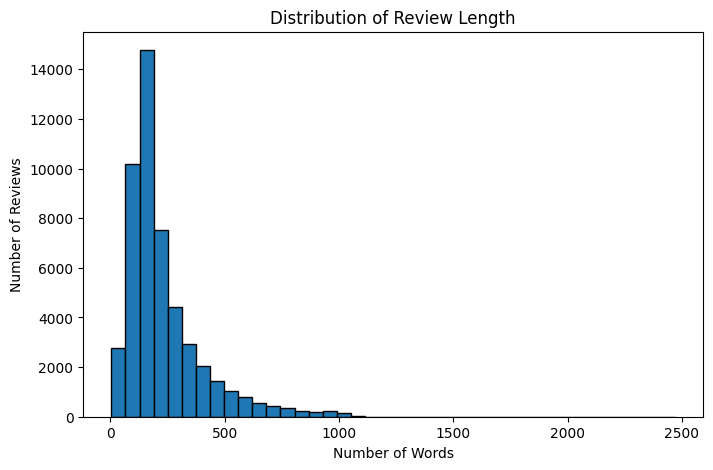

Total number of words: 11709196
First 20 words:
['i', 'rented', 'i', 'am', 'curious', 'yellow', 'from', 'my', 'video', 'store', 'because', 'of', 'all', 'the', 'controversy', 'that', 'surrounded', 'it', 'when', 'it']


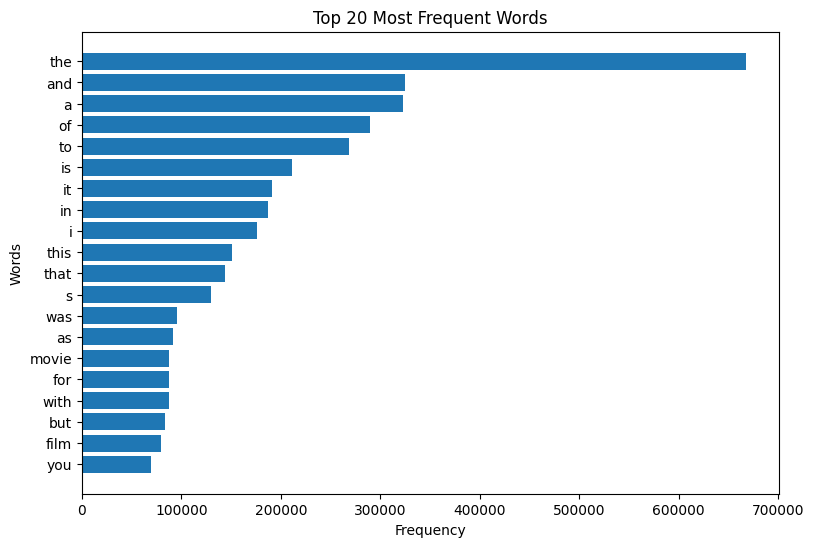

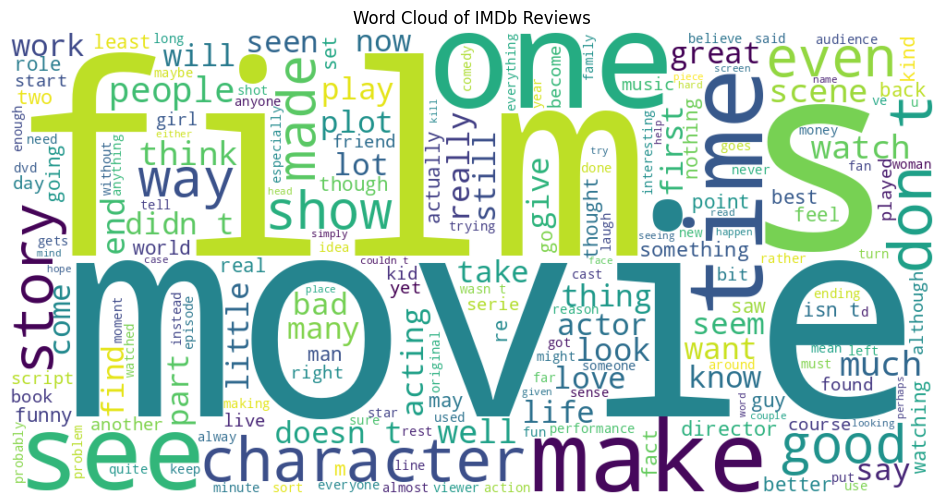

Top 20 Most Frequent Bigrams:
             Bigram  Frequency
15          ve seen       4168
14  special effects       2250
0          don know       2202
6        low budget       1824
5        looks like       1679
18         year old       1601
8        movie just       1543
16       waste time       1526
2        good movie       1520
13           sci fi       1393
17      watch movie       1379
10         new york       1317
4         look like       1313
1         don think       1305
19        years ago       1256
12        real life       1240
3       high school       1164
7    main character       1140
11      pretty good       1120
9        movie like       1095


In [18]:
# 5. DOCUMENT LENGTH DISTRIBUTION

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(df["word_count"], bins=40, edgecolor="black")

plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")
plt.title("Distribution of Review Length")

plt.show()


# 6. CREATE WORD LIST

# Using 'clean_text' instead of 'clean_review'
all_words = " ".join(df["clean_text"]).split()

print("Total number of words:", len(all_words))

print("First 20 words:")
print(all_words[:20])

# 7. MOST FREQUENT WORDS

from collections import Counter
import matplotlib.pyplot as plt

word_freq = Counter(all_words)

top_words = word_freq.most_common(20)

words = [word for word, count in top_words]
counts = [count for word, count in top_words]

plt.figure(figsize=(9, 6))

plt.barh(words[::-1], counts[::-1])

plt.xlabel("Frequency")
plt.ylabel("Words")
plt.title("Top 20 Most Frequent Words")

plt.show()

# 9. WORD CLOUD

from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Use all_words instead of the undefined filtered_words variable
clean_text_combined = " ".join(all_words)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(clean_text_combined)

plt.figure(figsize=(12, 6))

plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of IMDb Reviews")

plt.show()

# 10. BIGRAM ANALYSIS

from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

bigram_vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(2, 2),
    max_features=20
)

# Create bigram matrix
bigram_matrix = bigram_vectorizer.fit_transform(
    df["clean_text"]
)

# Calculate frequency of each bigram
bigram_counts = bigram_matrix.sum(axis=0).A1

# Get bigram names
bigram_names = bigram_vectorizer.get_feature_names_out()

# Create DataFrame
bigram_df = pd.DataFrame({
    "Bigram": bigram_names,
    "Frequency": bigram_counts
})

# Sort by frequency
bigram_df = bigram_df.sort_values(
    by="Frequency",
    ascending=False
)

print("Top 20 Most Frequent Bigrams:")
print(bigram_df)